# Problem 3 - Sharp Peak

For the following problem, let's try to follow the code as suggested in the BlueQubit [tutorial](https://app.bluequbit.io/tutorial/91OgcR5O1GqFpues)

First load the relevant libraries

In [1]:
# --- Setup ---
import os
import time
import warnings

# Optional internal flags you were using
# os.environ["BLUEQUBIT_PPS_DO_NO_USE_PARALLEL_COMPUTE"] = "1"
os.environ["BLUEQUBIT_DEQART_INTERNAL_DISABLE_STRICT_VALIDATIONS"] = "1"

warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from qiskit import QuantumCircuit, transpile
import bluequbit

# Optional: load .env file if present (pip install python-dotenv)
try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

# --- Auth ---
token = os.getenv("BLUEQUBIT_API_TOKEN")
if not token:
    raise RuntimeError(
        "Missing BLUEQUBIT_API_TOKEN. Set it in your shell or in a local .env file."
    )

bq = bluequbit.init(token)
print("BlueQubit client initialized successfully.")

[BQ-PYTHON-SDK][WARNING] - Beta version 0.18.1b1 of BlueQubit Python SDK is being used.


[BQ-PYTHON-SDK][INFO] - There is a newer version of BlueQubit Python SDK available on PyPI. We recommend upgrading. Run 'pip install --upgrade bluequbit' to upgrade from your version 0.18.1b1 to 0.18.3b1.
BlueQubit client initialized successfully.


Now, we can load the corresponding circuit

In [3]:
qc = QuantumCircuit.from_qasm_file('problems/P3_sharp_peak.qasm')

Let's visualize the circuit

Gates: OrderedDict([('u3', 399), ('cz', 178)])


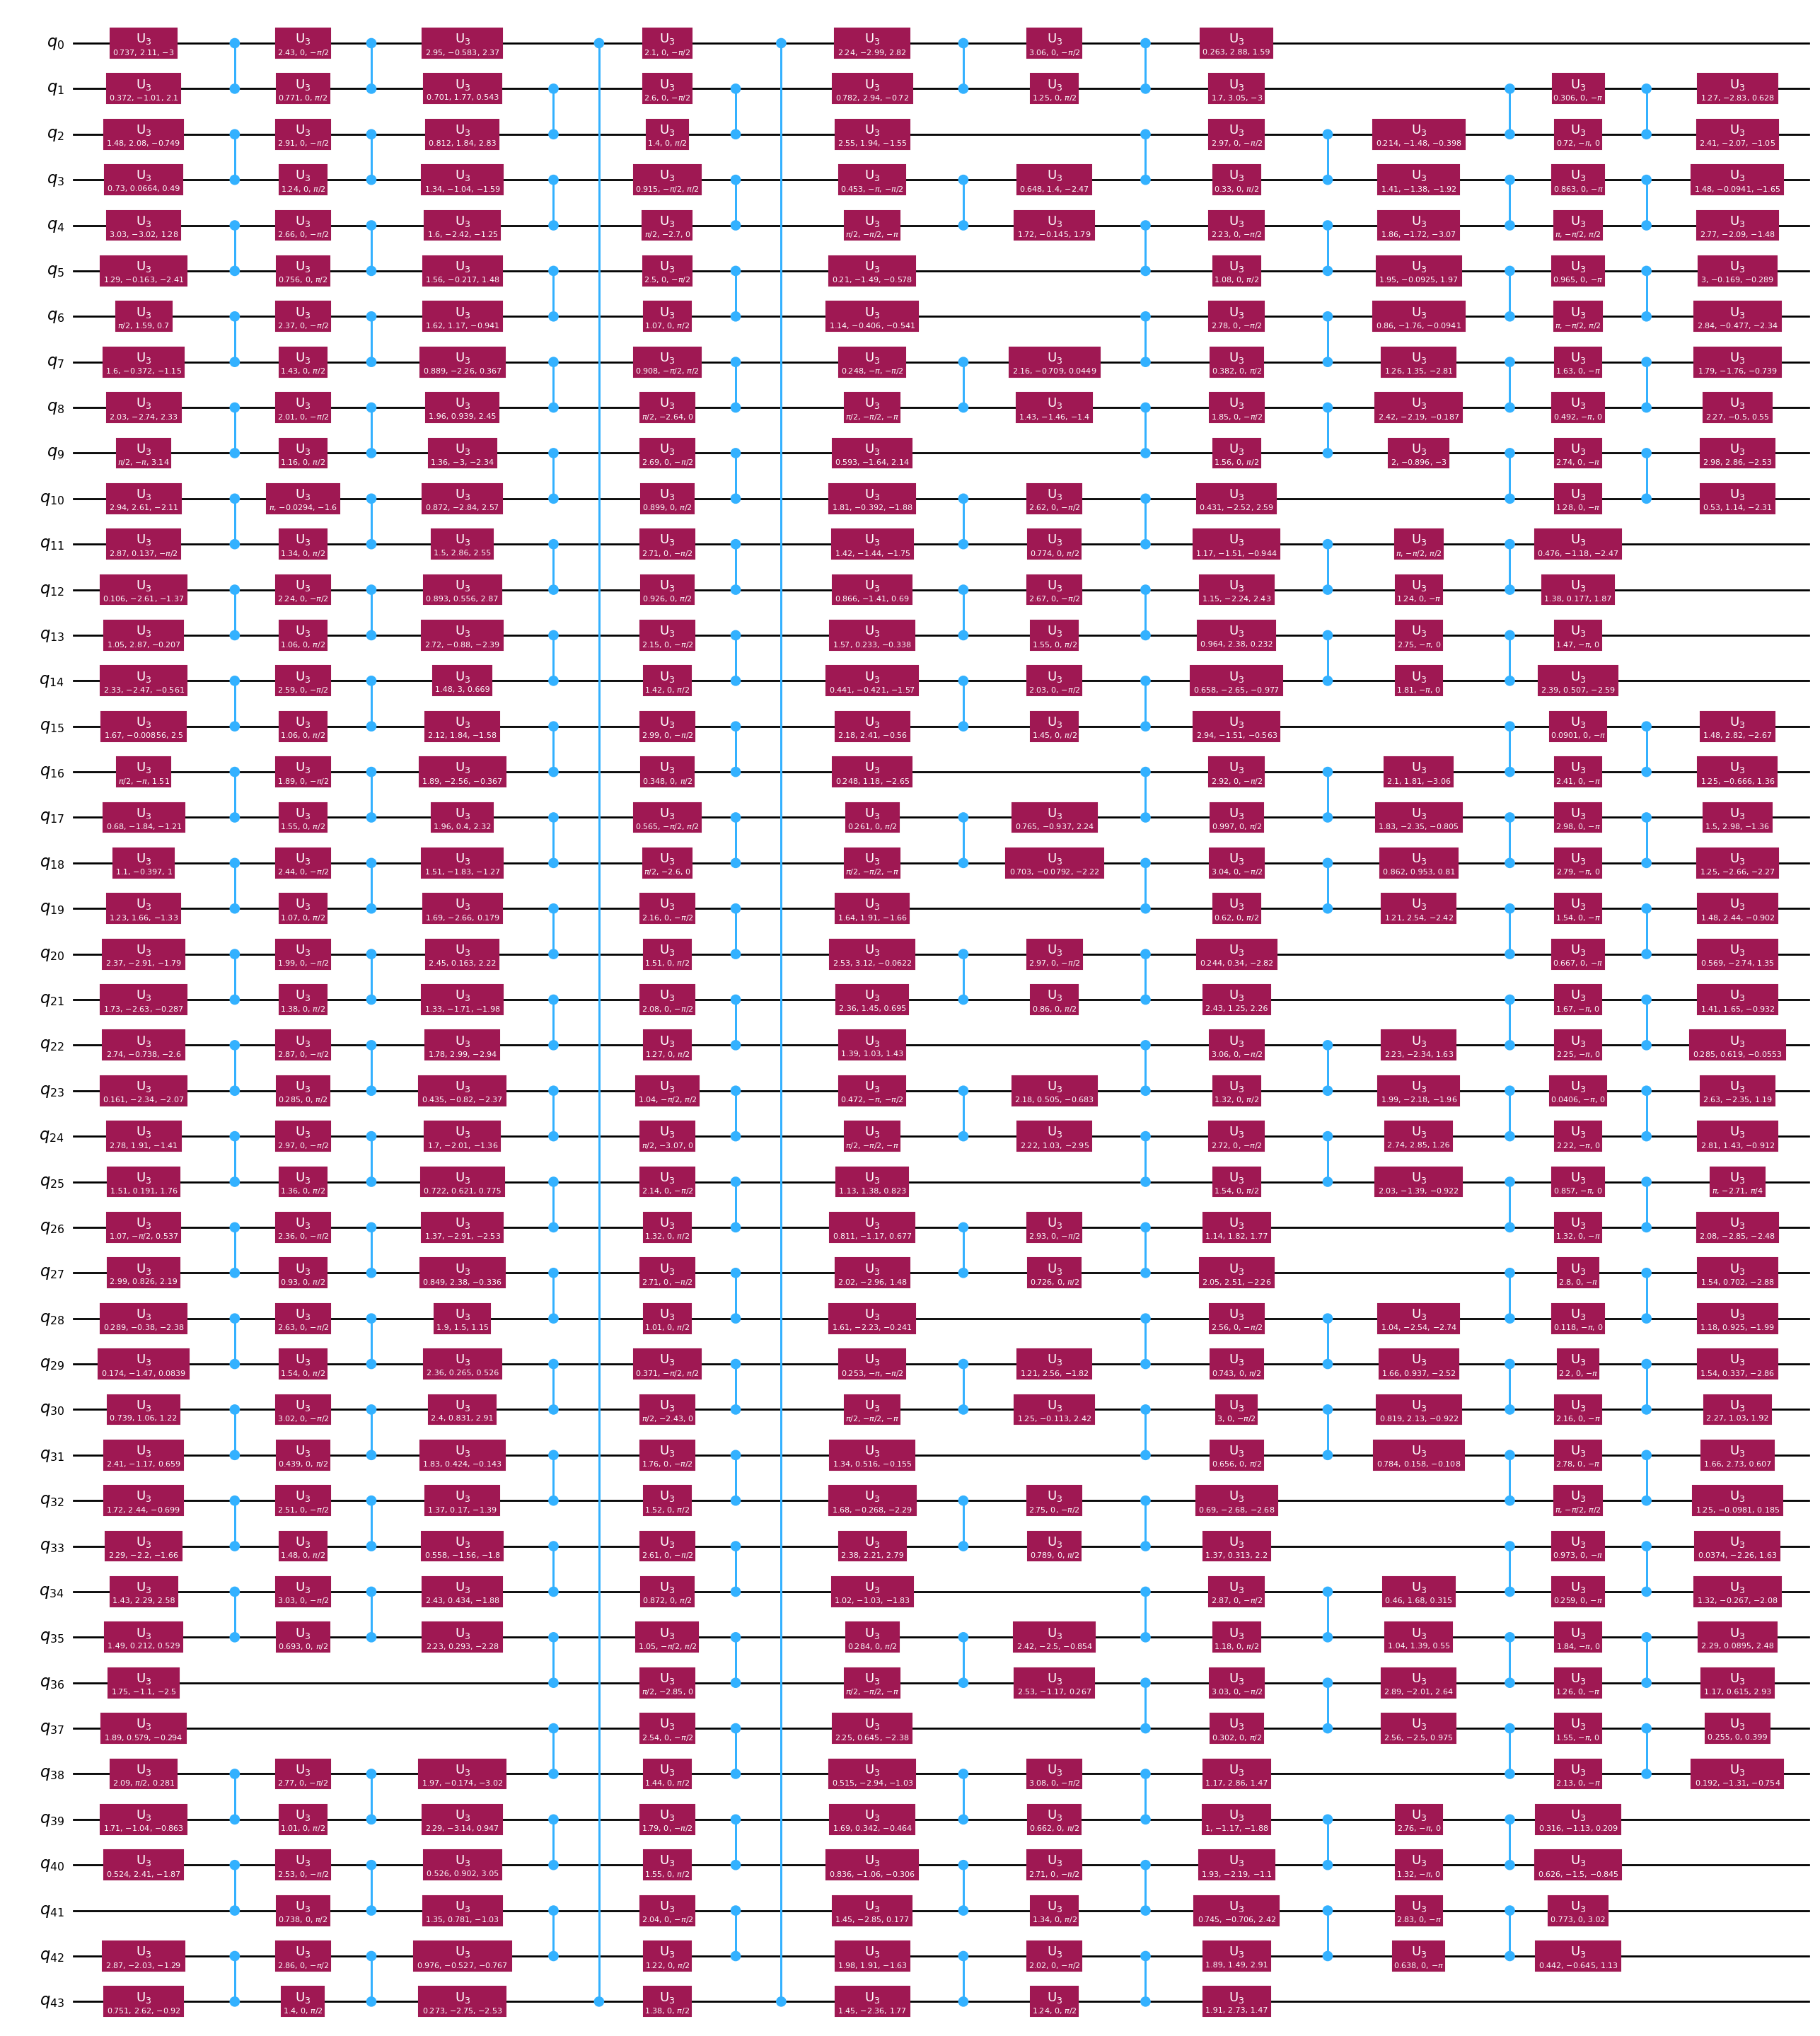

In [4]:
print(f"Gates: {qc.count_ops()}")
qc.draw("mpl", fold=-1)

This circuit looks complicated. We cannot solve it anymore with BlueQubit's Statevector Simulator as given in bluequbit's [tutorial](https://app.bluequbit.io/tutorial/91OgcR5O1GqFpues). The reason for it is that `device='cpu'` won't work anymore in the free version, since it's limited to max. 34 qubits as seen in bluequbit's [doc](https://app.bluequbit.io/docs#devices). Therefore, we switch to `device='mps.cpu'` which can handle up to 96 qubits. This is the MPS Simulator based on Quimb library, on CPUs. Let's try the standard settings in the chapter `Tree Line: MPS Simulations` of BlueQubit's tutorial mentioned before. In order to learn something from it, let's shortly explain what the options mean:
*  Bond dimension (mps_bond_dimension): The bond dimension controls how much entanglement the MPS representation is allowed to capture.
During each gate application, the MPS is compressed using an SVD, and only the $\chi$ largest Schmidt coefficients are retained, where $\chi$ is the chosen bond dimension. A larger bond dimension produces a more faithful approximation of the true quantum state, but at the cost of increased memory usage and longer simulation time.
* Number of shots (shots): For a fixed MPS approximation, the number of shots determines the statistical accuracy of the sampled output distribution. Higher shot counts yield histograms that more closely match the probabilities encoded in the MPS state. However, increasing the number of shots directly increases runtime, since each shot corresponds to an independent sample drawn from the MPS.

In [6]:
# Run the circuit using BlueQubit's MPS simulator.

results_mps = bq.run(
    qc,
    device="mps.cpu",
    shots=500,
    options={"mps_bond_dimension": 32},
)

print(f"MPS simulation runtime: {results_mps.run_time_ms} ms")

[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: WZRhO799wPO58YCO, device: mps.cpu, run status: PENDING, created on: 2026-03-05 20:43:14 UTC, estimated runtime: 9922 ms, estimated cost: $0.00, num qubits: 44, shots: 500
[BQ-PYTHON-SDK][INFO] - Status changed: Job ID: WZRhO799wPO58YCO. From PENDING to RUNNING.
MPS simulation runtime: 12970 ms


In [7]:
# Extract the sampled bitstring counts from the MPS simulation
counts = results_mps.get_counts()

# Sort the bitstrings by frequency (descending) and take the top 10
top10_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:10]

# The bitstring with the highest count is our candidate peak bitstring
peak_bitstring_mps = top10_counts[0][0]

print("Top 10 most frequent bitstrings from MPS Simulation: \n")
for bitstring, count in top10_counts:
    print(f"  {bitstring}: {count}")
print(f"\nPeak bitstring inferred from MPS samples: {peak_bitstring_mps}")

Top 10 most frequent bitstrings from MPS Simulation: 

  10001101010101010000011111001101000100011010: 70
  10001101010101010001101111001101000100011010: 6
  10010001010101010000011111001101000100011010: 5
  10001101010101010000011111001100010100011010: 4
  10001101010111000000011111001101000100011010: 4
  10001101010100100000011111001101000100011010: 4
  10001101010101010000011001001101000100011010: 3
  10001101010101010000011111001100110100011010: 3
  10001101010101010001010111001101000100011010: 3
  10001101010101010000011111001010000100011010: 3

Peak bitstring inferred from MPS samples: 10001101010101010000011111001101000100011010


It shows that `10001101010101010000011111001101000100011010` is by far the most probable state to get with this quantum circuit. We obtained the correct answer, but did we really understand what `Schmidt coefficients` are for example? Maybe not, so let's give a better explanation below: